In [ ]:
#L1

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,  models, callbacks
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train),(x_test, y_test)=tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [ ]:
print(x_train.shape)

(60000, 784)


In [ ]:
x_train_small = x_train[:1000]
y_train_small = y_train[:1000]

In [ ]:
model_overfit = models.Sequential([
    layers.Dense(2000, activation='relu', input_shape=(784,)),
    layers.Dense(2000, activation='relu'),
    layers.Dense(2000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_overfit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
chk_point_overfit = callbacks.ModelCheckpoint(
    filepath="best_overfit_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

chk_point_l1 = callbacks.ModelCheckpoint(
    filepath="best_l1_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

In [ ]:
history_overfit = model_overfit.fit(
    x_train_small, y_train_small,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[chk_point_overfit]
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5814 - loss: 1.2993
Epoch 1: val_accuracy improved from None to 0.80430, saving model to best_overfit_model.keras

Epoch 1: finished saving model to best_overfit_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 499ms/step - accuracy: 0.7360 - loss: 0.8626 - val_accuracy: 0.8043 - val_loss: 0.5953
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9367 - loss: 0.2084
Epoch 2: val_accuracy improved from 0.80430 to 0.81460, saving model to best_overfit_model.keras

Epoch 2: finished saving model to best_overfit_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 345ms/step - accuracy: 0.9310 - loss: 0.2412 - val_accuracy: 0.8146 - val_loss: 0.6424
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9369 - loss: 0.1740
Epoch 3: val_accuracy improved from 0.81460 to 0.87880, saving model to best_overfit_model.keras

Epoch 3: finished saving model to best_overfit_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/s

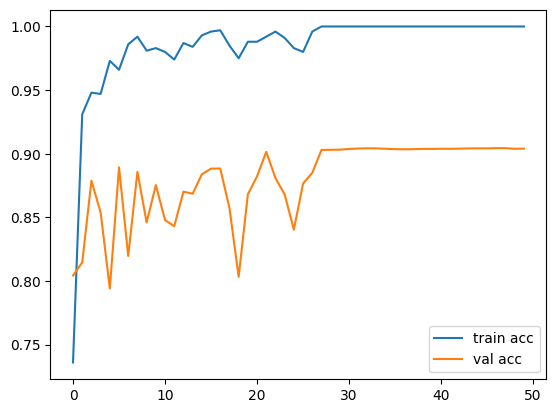

In [ ]:
plt.plot(history_overfit.history['accuracy'], label='train acc')
plt.plot(history_overfit.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [ ]:
model_l1 = models.Sequential([
    layers.Dense(2000, activation='relu', input_shape=(784,),
                 kernel_regularizer=regularizers.l1(0.001)),

    layers.Dense(2000, activation='relu',
                 kernel_regularizer=regularizers.l1(0.001)),

    layers.Dense(2000, activation='relu',
                 kernel_regularizer=regularizers.l1(0.001)),

    layers.Dense(10, activation='softmax')
])

In [ ]:
model_l1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_l1 = model_l1.fit(
    x_train_small, y_train_small,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[chk_point_l1]
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.4695 - loss: 137.9793
Epoch 1: val_accuracy improved from None to 0.70590, saving model to best_l1_model.keras

Epoch 1: finished saving model to best_l1_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 866ms/step - accuracy: 0.5930 - loss: 95.4056 - val_accuracy: 0.7059 - val_loss: 25.2528
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7723 - loss: 17.1485
Epoch 2: val_accuracy did not improve from 0.70590
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 493ms/step - accuracy: 0.7590 - loss: 12.3760 - val_accuracy: 0.6910 - val_loss: 5.6844
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7852 - loss: 4.6988
Epoch 3: val_accuracy improved from 0.70590 to 0.75210, saving model to best_l1_model.keras

Epoch 3: finished saving model to best_l1_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 490ms/step - accuracy: 0.7780 - loss: 4.1349 - val_accuracy: 0.7521 - val_loss: 3.3667
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s

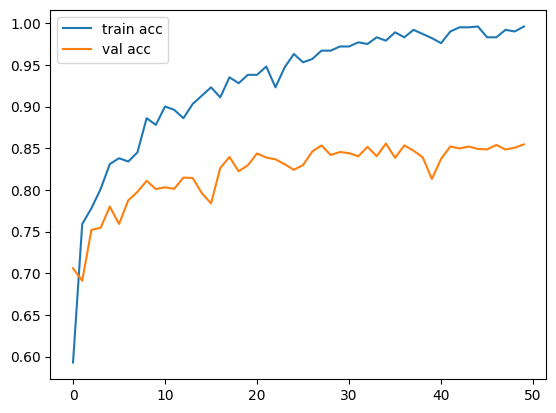

In [ ]:
plt.plot(history_l1.history['accuracy'], label='train acc')
plt.plot(history_l1.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()